# Bounding Boxes & IoU

### What Is A Bounding Box?

A bounding box is a rectangle drawn around a detected object.

It is described by 4 numbers:

```
(x1, y1) ─────────┐
   │              │
   │    object    │
   │              │
   └───────── (x2, y2)
```

| Value | Meaning |
| ----- | ------- |
| `x1, y1` | Top-left corner |
| `x2, y2` | Bottom-right corner |

Example:

```python
box = (100, 50, 300, 250)
```

We have already been using bounding boxes — MTCNN returned them for every face it detected, and we drew them using `cv2.rectangle`.

### The Duplicate Box Problem

Object detectors like YOLO run on every cell of a grid.

Multiple nearby cells will often detect the same object:

```
┌─────────────────┐
│  box1 (0.91) ─┐ │
│  box2 (0.88)─┐│ │  ← all detecting the same dog
│  box3 (0.45)┐││ │
│             🐕 │
└─────────────────┘
```

We need a way to:

1. Measure how much two boxes overlap
2. Decide if they are detecting the same object
3. Keep only the best one

This is solved by **IoU** and **NMS**.

### IoU — Intersection over Union

IoU measures how much two boxes overlap.

```
IoU = Intersection Area / Union Area
```

**Intersection** — only the overlapping region:

```
┌────┐
│    │
│────┼───┐
│////│   │
└────|───┘
```

**Union** — everything covered by either box:

```
┌────┐
│////│
│////┼───┐
│////////│
└────────┘
```

| IoU Value | Meaning |
| --------- | ------- |
| `1.0` | Perfect overlap — identical boxes |
| `0.5+` | Likely detecting the same object |
| `0.0` | No overlap at all |

Why divide by union and not just use intersection area?

Because a large box could have a big intersection with a tiny box even if they barely match.
Dividing by union makes it a fair, normalized score between 0 and 1.

### Calculating Intersection

Given two boxes:

```
Box A: (100, 100, 300, 300)
Box B: (200, 200, 400, 400)
```

The intersection corners are found by:

```
x1 = max(ax1, bx1) = max(100, 200) = 200  ← larger left edge
y1 = max(ay1, by1) = max(100, 200) = 200  ← larger top edge
x2 = min(ax2, bx2) = min(300, 400) = 300  ← smaller right edge
y2 = min(ay2, by2) = min(300, 400) = 300  ← smaller bottom edge
```

So intersection box = `(200, 200, 300, 300)`

Why max for top-left and min for bottom-right?

- The overlapping region starts where **both** boxes have already started → take the larger start
- The overlapping region ends where **either** box ends first → take the smaller end

Then:

```python
width  = x2 - x1  # 300 - 200 = 100
height = y2 - y1  # 300 - 200 = 100
intersection = width * height  # 10,000
```

### Calculating Union

Union = everything covered by either box.

```python
union = area_A + area_B - intersection
```

We subtract intersection because adding both boxes counts the overlapping region **twice**.

### IoU From Scratch

In [20]:
def calculate_iou(boxA, boxB):
    
    # Unpack boxes
    ax1, ay1, ax2, ay2 = boxA
    bx1, by1, bx2, by2 = boxB
    
    # Intersection
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    
    # If boxes don't overlap, width or height will be negative
    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)
    intersection = inter_w * inter_h
    
    # Union
    area_A = (ax2 - ax1) * (ay2 - ay1)
    area_B = (bx2 - bx1) * (by2 - by1)
    union = area_A + area_B - intersection
    
    # IoU
    if union == 0:
        return 0.0
    
    return intersection / union

#### `max(0, ix2 - ix1)`

If the boxes don't overlap at all, `ix2 - ix1` will be negative.

We clamp it to 0 so we never get a negative intersection area.

#### `if union == 0`

Safety check — prevents division by zero if both boxes have zero area.

### Testing IoU

In [21]:
# Same box → should be 1.0
boxA = (100, 100, 300, 300)
boxB = (100, 100, 300, 300)
print(f"Same box:         {calculate_iou(boxA, boxB):.2f}")  # 1.00

# Partial overlap
boxA = (100, 100, 300, 300)
boxB = (200, 200, 400, 400)
print(f"Partial overlap:  {calculate_iou(boxA, boxB):.2f}")  # 0.14

# No overlap
boxA = (0,   0,  100, 100)
boxB = (200, 200, 400, 400)
print(f"No overlap:       {calculate_iou(boxA, boxB):.2f}")  # 0.00

# One box inside another
boxA = (100, 100, 300, 300)
boxB = (100, 100, 200, 200)
print(f"Box inside box:   {calculate_iou(boxA, boxB):.2f}")  # 0.11

Same box:         1.00
Partial overlap:  0.14
No overlap:       0.00
Box inside box:   0.25


### Visualizing Bounding Boxes & IoU

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_boxes(boxA, boxB, title=""):
    
    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 500)
    ax.invert_yaxis()
    
    # Draw Box A
    ax.add_patch(patches.Rectangle(
        (boxA[0], boxA[1]),
        boxA[2] - boxA[0],
        boxA[3] - boxA[1],
        linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.3, label='Box A'
    ))
    
    # Draw Box B
    ax.add_patch(patches.Rectangle(
        (boxB[0], boxB[1]),
        boxB[2] - boxB[0],
        boxB[3] - boxB[1],
        linewidth=2, edgecolor='red', facecolor='red', alpha=0.3, label='Box B'
    ))
    
    # Draw Intersection
    ix1 = max(boxA[0], boxB[0])
    iy1 = max(boxA[1], boxB[1])
    ix2 = min(boxA[2], boxB[2])
    iy2 = min(boxA[3], boxB[3])
    
    if ix2 > ix1 and iy2 > iy1:
        ax.add_patch(patches.Rectangle(
            (ix1, iy1), ix2 - ix1, iy2 - iy1,
            linewidth=2, edgecolor='green', facecolor='green', alpha=0.5, label='Intersection'
        ))
    
    iou = calculate_iou(boxA, boxB)
    ax.set_title(f"{title}  |  IoU: {iou:.2f}")
    ax.legend()
    plt.tight_layout()
    plt.show()

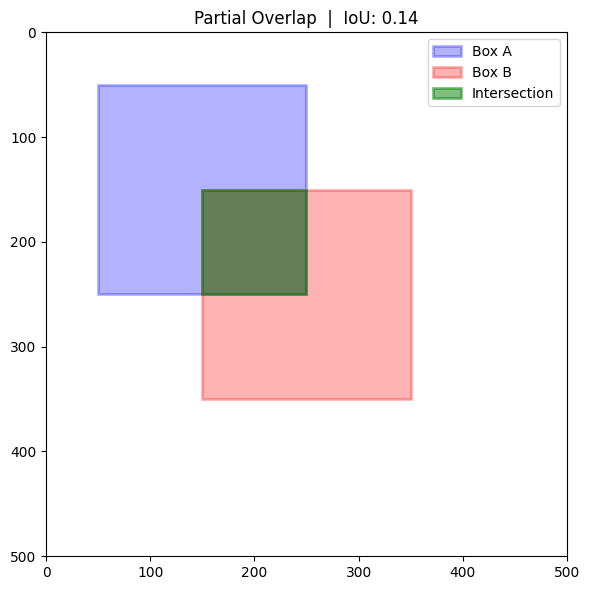

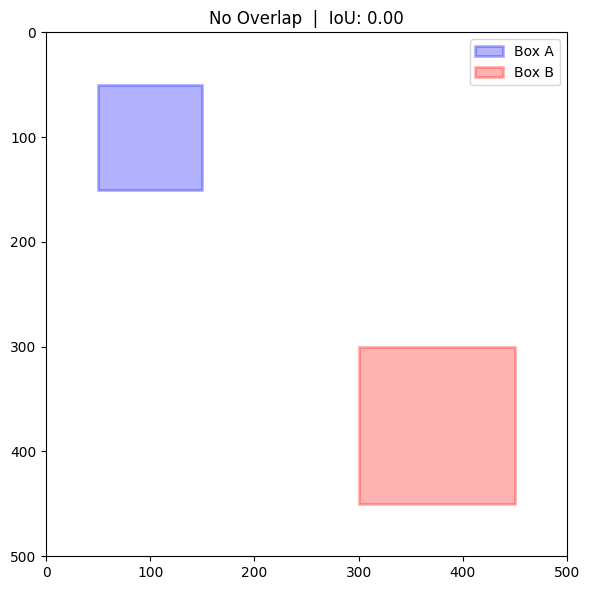

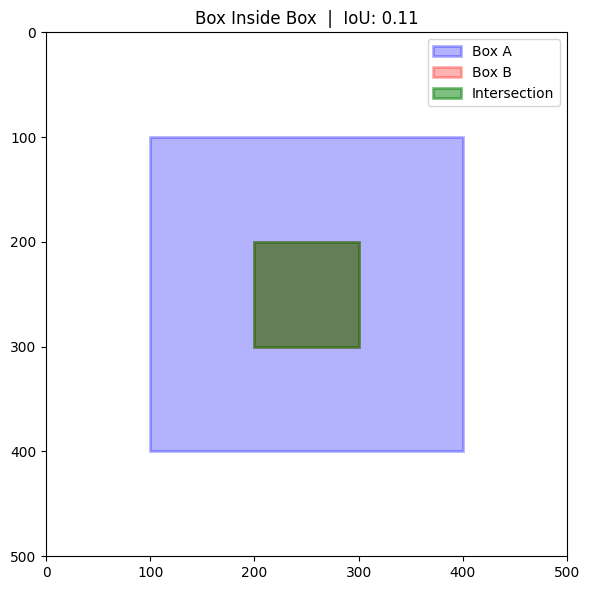

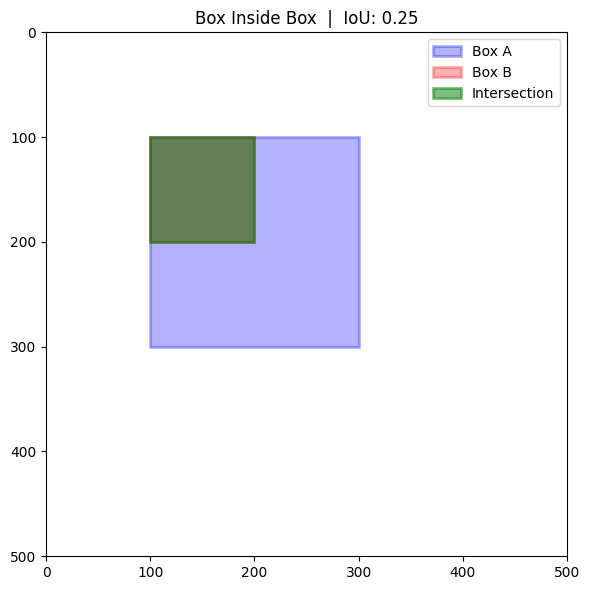

In [23]:
# Partial overlap
draw_boxes((50, 50, 250, 250), (150, 150, 350, 350), "Partial Overlap")

# No overlap
draw_boxes((50, 50, 150, 150), (300, 300, 450, 450), "No Overlap")

# Box inside box
draw_boxes((100, 100, 400, 400), (200, 200, 300, 300), "Box Inside Box")
draw_boxes((100, 100, 300, 300), (100, 100, 200, 200), "Box Inside Box")

### NMS — Non-Maximum Suppression

IoU tells us how much two boxes overlap.

NMS uses IoU to **remove duplicate detections** and keep only the best box per object.

```
Before NMS                After NMS

┌─────────────────┐       ┌─────────────────┐
│  box1 (0.91) ─┐ │       │  box1 (0.91)    │
│  box2 (0.88)─┐│ │  →    │                 │
│  box3 (0.45)┐││ │       │       🐕        │
│             🐕  │       └─────────────────┘
└─────────────────┘
```

NMS algorithm:

```
1. Sort all boxes by confidence (highest first)
2. Take the highest confidence box → keep it
3. Remove all other boxes that overlap it heavily (IoU > threshold)
4. Repeat from step 2 with remaining boxes
```

### NMS From Scratch

In [24]:
def nms(boxes, scores, iou_threshold=0.5):
    """
    boxes         : list of (x1, y1, x2, y2)
    scores        : confidence score for each box
    iou_threshold : boxes overlapping more than this are removed
    """
    
    # Sort boxes by confidence — highest first
    indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    
    kept = []
    
    while indices:
        
        # Always keep the current best box
        best = indices[0]
        kept.append(best)
        
        # Remove boxes that overlap too much with the best box
        indices = [
            i for i in indices[1:]
            if calculate_iou(boxes[best], boxes[i]) < iou_threshold
        ]
    
    return kept

#### `sorted(..., key=lambda i: scores[i], reverse=True)`

Sorts by score descending — highest confidence box comes first.

#### `best = indices[0]`

The current highest confidence box is always kept.

#### `if calculate_iou(...) < iou_threshold`

Keep a box only if it does **not** heavily overlap the best box.
If it does overlap → it's a duplicate → discard it.

### Testing NMS

In [25]:
# Three boxes detecting the same dog + one separate box for a cat
boxes = [
    (100, 100, 300, 300),  # dog box 1
    (110, 110, 310, 310),  # dog box 2 (slightly shifted)
    (120, 120, 320, 320),  # dog box 3 (slightly shifted)
    (400, 400, 500, 500),  # cat box (completely separate)
]

scores = [0.91, 0.88, 0.45, 0.76]

kept_indices = nms(boxes, scores, iou_threshold=0.5)

print("Kept boxes:")
for i in kept_indices:
    print(f"  Box {i}: {boxes[i]}  score: {scores[i]}")

Kept boxes:
  Box 0: (100, 100, 300, 300)  score: 0.91
  Box 3: (400, 400, 500, 500)  score: 0.76


Expected output:

```
Kept boxes:
  Box 0: (100, 100, 300, 300)  score: 0.91   ← best dog box kept
  Box 3: (400, 400, 500, 500)  score: 0.76   ← cat box kept (no overlap)
```

Box 1 and Box 2 were removed — they overlapped Box 0 too heavily.

### Visualizing NMS

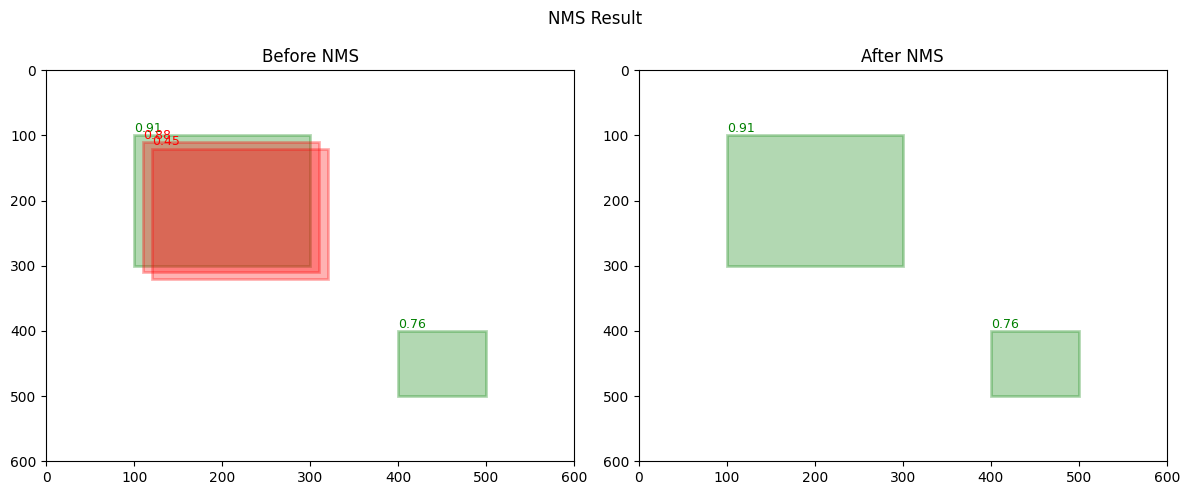

In [26]:
def draw_nms(boxes, scores, kept_indices, title="NMS Result"):
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for ax, show_kept_only, subtitle in zip(
        axes,
        [False, True],
        ["Before NMS", "After NMS"]
    ):
        ax.set_xlim(0, 600)
        ax.set_ylim(0, 600)
        ax.invert_yaxis()
        ax.set_title(subtitle)
        
        for i, (box, score) in enumerate(zip(boxes, scores)):
            
            if show_kept_only and i not in kept_indices:
                continue
            
            color = 'green' if i in kept_indices else 'red'
            
            ax.add_patch(patches.Rectangle(
                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                linewidth=2, edgecolor=color, facecolor=color, alpha=0.3
            ))
            ax.text(box[0], box[1] - 5, f"{score:.2f}", color=color, fontsize=9)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

draw_nms(boxes, scores, kept_indices)

### Summary

| Concept | What It Does |
| ------- | ------------ |
| Bounding Box | Rectangle around object described by `(x1, y1, x2, y2)` |
| Intersection | Overlapping area between two boxes |
| Union | Total area covered by either box |
| IoU | `Intersection / Union` — normalized overlap score 0→1 |
| Confidence | How sure the model is an object exists in this box |
| NMS | Removes duplicate boxes, keeps highest confidence per object |

We built both IoU and NMS from scratch.

In practice, YOLO handles all of this internally — but now when we see the output, we know exactly what is happening under the hood.